<a href="https://colab.research.google.com/github/AndrewDavidRatnam/HuggingFace_IntroToAudioCourse/blob/main/HF_AudioCourse_Unit_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Audio classification with a pipeline

In [ ]:
from datasets import load_dataset
from datasets import Audio

minds = load_dataset("PolyAI/minds14", name="en-AU", split="train")
minds = minds.cast_column("audio", Audio(sampling_rate=16_000))



In [ ]:
from transformers import pipeline

classifier = pipeline(
    "audio-classification",
    model = "anton-l/xtreme_s_xlsr_300m_minds14",
)

In [ ]:
example = minds[0]
example

In [ ]:
classifier(example["audio"]["array"])

In [ ]:
id2label = minds.features["intent_class"].int2str
id2label(example["intent_class"])

# Automatic speech recognition with a pipeline

In [ ]:
from transformers import pipeline

asr = pipeline("automatic-speech-recognition")



In [ ]:
example = minds[0]

asr(example["audio"]["array"])

In [ ]:
example["english_transcription"]

DANKE?

In [ ]:
from datasets import load_dataset
from datasets import Audio

minds = load_dataset("PolyAI/minds14", name="de-DE", split="train")
minds = minds.cast_column("audio", Audio(sampling_rate=16_000))

In [ ]:
example = minds[0]
example["transcription"]

In [ ]:
from transformers import pipeline

asr = pipeline("automatic-speech-recognition", model="maxidl/wav2vec2-large-xlsr-german")
asr(example["audio"]["array"])

## WHy you should always use a ready-to-use-pipeline


*   a pre-trained model may exist that already solves your task really well, saving you plenty of time
*   pipeline() takes care of all the pre/post-processing for you, so you don’t have to worry about getting the data into the right format for a model
* if the result isn’t ideal, this still gives you a quick baseline for future fine-tuning

* once you fine-tune a model on your custom data and share it on Hub, the whole community will be able to use it quickly and effortlessly via the pipeline() method making AI more accessible.

# Audio Generation with pipeline

In [ ]:
!pip install --upgrade transformers

In [ ]:
from transformers import pipeline

pipe = pipeline("text-to-speech", model="suno/bark-small")



In [ ]:
text = "Ladybugs have had important roles in culture and religion, being associated with luck, love, fertility and prophecy. "
output = pipe(text)

In [ ]:
from IPython.display import Audio
Audio(output["audio"].squeeze(), rate=output["sampling_rate"])

Yeah the rest of the examples are just gonna waste compute
```
song = "♪ In the jungle, the mighty jungle, the ladybug was seen. ♪ "
output = pipe(song)
Audio(output["audio"].squeeze(), rate=output["sampling_rate"])
```

```
music_pipe = pipeline("text-to-audio", model="facebook/musicgen-small")
text = "90s rock song with electric guitar and heavy drums"
forward_params = {"max_new_tokens": 512} #control length of output

output = music_pipe(text, forward_params=forward_params)
Audio(output["audio"][0], rate=output["sampling_rate"])
```


# Hands-on Excercise

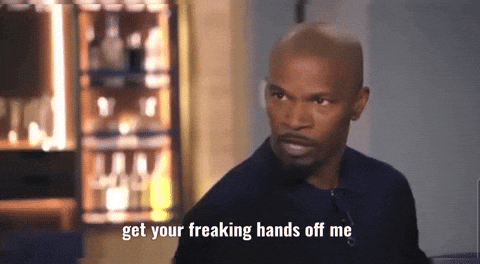

In [ ]:
from datasets import load_dataset

ds = load_dataset("facebook/voxpopuli", name="de", streaming=True)

In [ ]:
ds_head = ds["train"].take(3)

In [ ]:
example = list(ds_head)[-1]

In [ ]:
example

In [ ]:
from IPython.display import Audio

Audio(example["audio"]["array"], rate=16000)

In [ ]:
import librosa
import matplotlib.pyplot as plt
import librosa.display



In [ ]:
array = example["audio"]["array"]
sr = example["audio"]["sampling_rate"]


In [ ]:
plt.figure().set_figwidth(12)
librosa.display.waveshow(array,sr=sr)
plt.show()

In [ ]:
import numpy as np

D = librosa.stft(array)

S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)


In [ ]:
plt.figure().set_figwidth(12)
librosa.display.specshow(S_db, x_axis="time", y_axis="hz")
plt.colorbar()
plt.show()

In [ ]:
from transformers import pipeline
asr = pipeline("automatic-speech-recognition", model="facebook/wav2vec2-large-xlsr-53-german")

print(asr(example["audio"]["array"]))
print(example["raw_text"])

In [ ]:
from IPython.display import Audio
Audio(example["audio"]["array"], rate=16000)